In [1]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from scipy.optimize import curve_fit

In [2]:
data = rf.read_all('ampdata')
#fghz = data1['trace0'].f/1e9
fghz = data['trace0'].f/1e9

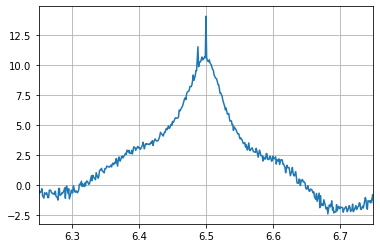

In [3]:
plt.plot(fghz,data['trace30'].s_db[:,0,0])
plt.xlim(6.25,6.75)
plt.grid()

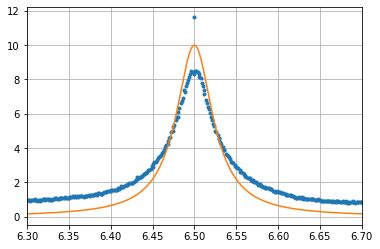

In [4]:
plt.plot(fghz,np.abs(data['trace50'].s[:,0,0]),'.')
plt.plot(fghz,0.007/((fghz - 6.5)**2 + 0.0007))

plt.xlim(6.3,6.7)
plt.grid()

In [7]:
gain = np.abs(data['trace50'].s[:,0,0])

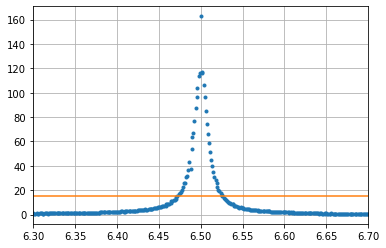

In [10]:
def peakfunc(x,a,b):
    return a*np.exp(-(x-6.5)**2/(2*b*b))
popt, pcov = curve_fit(peakfunc, fghz[100:300],np.abs(data['trace40'].s[100:300,0,0])**2)
plt.plot(fghz,np.abs(data['trace40'].s[:,0,0])**2,'.')
plt.plot(fghz,peakfunc2(fghz,popt[0],popt[1]))

plt.xlim(6.3,6.7)
plt.grid()

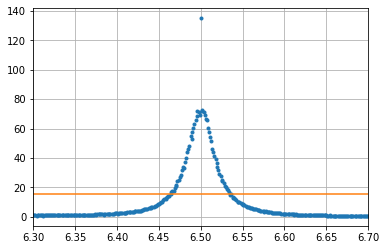

In [11]:
def peakfunc2(x,a,b):
    return a*np.exp(-(x-6.5)**2/(2*b*b))
popt, pcov = curve_fit(peakfunc, fghz[100:300],np.abs(data['trace50'].s[100:300,0,0])**2)
plt.plot(fghz,np.abs(data['trace50'].s[:,0,0])**2,'.')
plt.plot(fghz,peakfunc(fghz,popt[0],popt[1]))

plt.xlim(6.3,6.7)
plt.grid()

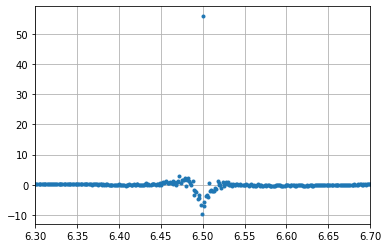

In [75]:
plt.plot(fghz,np.abs(data['trace50'].s[:,0,0])**2 - peakfunc(fghz,popt[0],popt[1]),'.')

plt.xlim(6.3,6.7)
plt.grid()

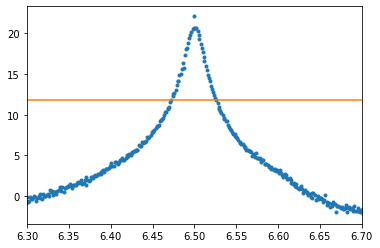

In [12]:
def peakfunc2(x,a,b):
    return a*np.exp(-(x-6.5)**2/(2*b*b))
popt, pcov = curve_fit(peakfunc, fghz[100:300],np.abs(data['trace40'].s[100:300,0,0])**2)
#plt.plot(fghz,np.abs(data['trace40'].s[:,0,0])**2,'.')
#plt.plot(fghz,peakfunc(fghz,popt[0],popt[1]))

plt.xlim(6.3,6.7)
plt.grid()
plt.plot(fghz,20*np.log10(np.abs(data['trace40'].s[:,0,0])),'.')
plt.plot(fghz,10*np.log10(peakfunc(fghz,popt[0],popt[1])))

plt.xlim(6.3,6.7)
plt.grid()

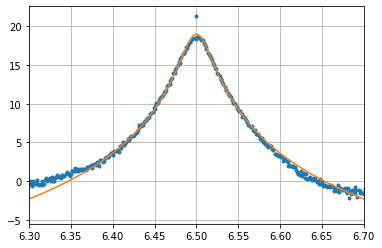

In [23]:
def peakfunc2(x,a,b):
    return a*np.exp(-(x-6.5)**2/(2*b*b))
popt, pcov = curve_fit(peakfunc, fghz[100:300],np.abs(data['trace50'].s[100:300,0,0])**2)
#plt.plot(fghz,np.abs(data['trace40'].s[:,0,0])**2,'.')
#plt.plot(fghz,peakfunc(fghz,popt[0],popt[1]))

plt.plot(fghz,20*np.log10(np.abs(data['trace50'].s[:,0,0])),'.')
plt.plot(fghz,10*np.log10(peakfunc(fghz,popt[0],popt[1])))
plt.xlim(6.3,6.7)
plt.grid()


In [24]:
fitgain = 10*np.log10(peakfunc(fghz,popt[0],popt[1]))
rawgain = 20*np.log10(np.abs(data['trace50'].s[:,0,0]))


In [39]:
fitgain.max()

18.988910202067647

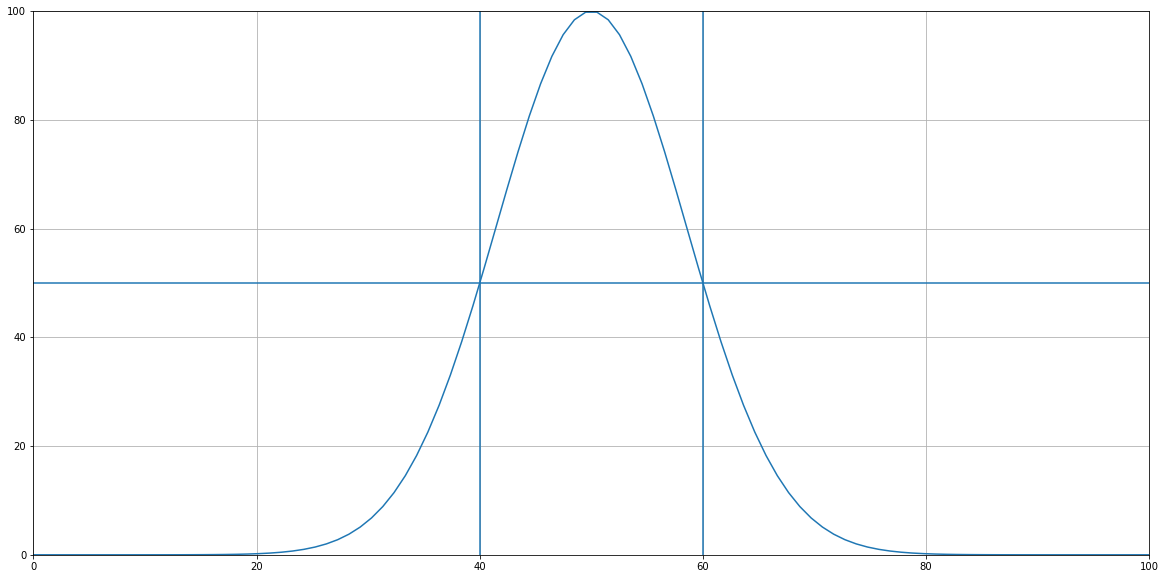

In [77]:
def gaussian(x,x0,fwhm,height):
    return height*np.exp(-(x - x0)**2/(fwhm*fwhm/2.775))
x = np.linspace(0,100,100)
y  = gaussian(x,50,20,100)
plt.subplots(figsize=(20,10))
plt.plot(x,y)
plt.vlines(40,0,100)
plt.vlines(60,0,100)
plt.hlines(50,0,100)
plt.xlim(0,100)
plt.ylim(0,100)
plt.grid()

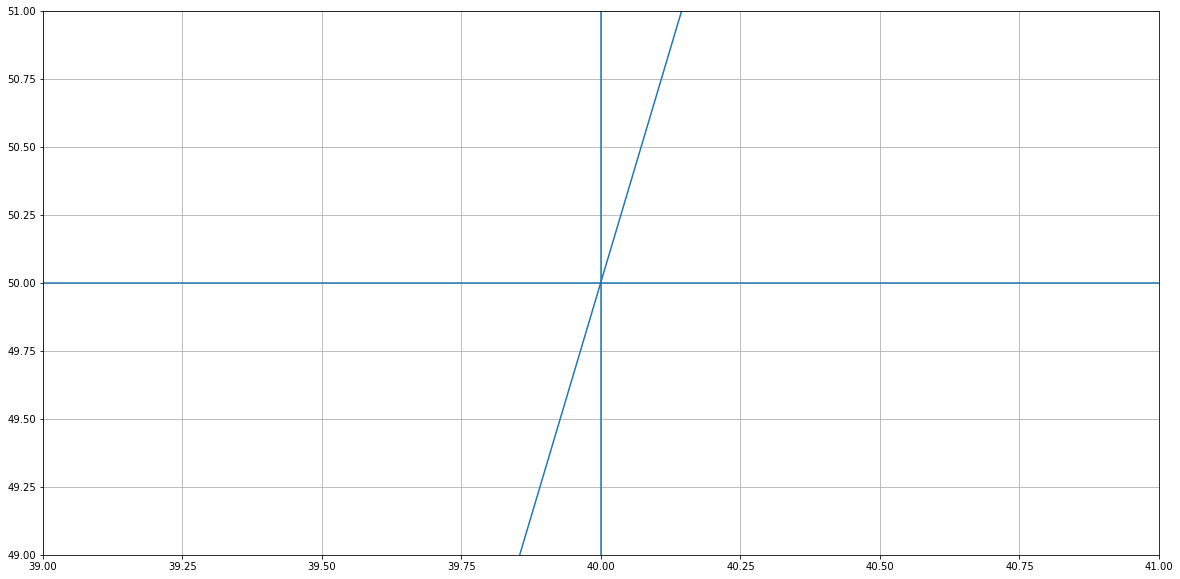

In [79]:
def gaussian(x,x0,fwhm,height):
    return height*np.exp(-(x - x0)**2/(fwhm*fwhm/2.775))
x = np.linspace(0,100,100)
y = gaussian(x,50,20,100)
plt.subplots(figsize=(20,10))
plt.plot(x,y,"+-")
plt.vlines(40,0,100)
plt.vlines(60,0,100)
plt.hlines(50,0,100)
plt.xlim(39,41)
plt.ylim(49,51)
plt.grid()

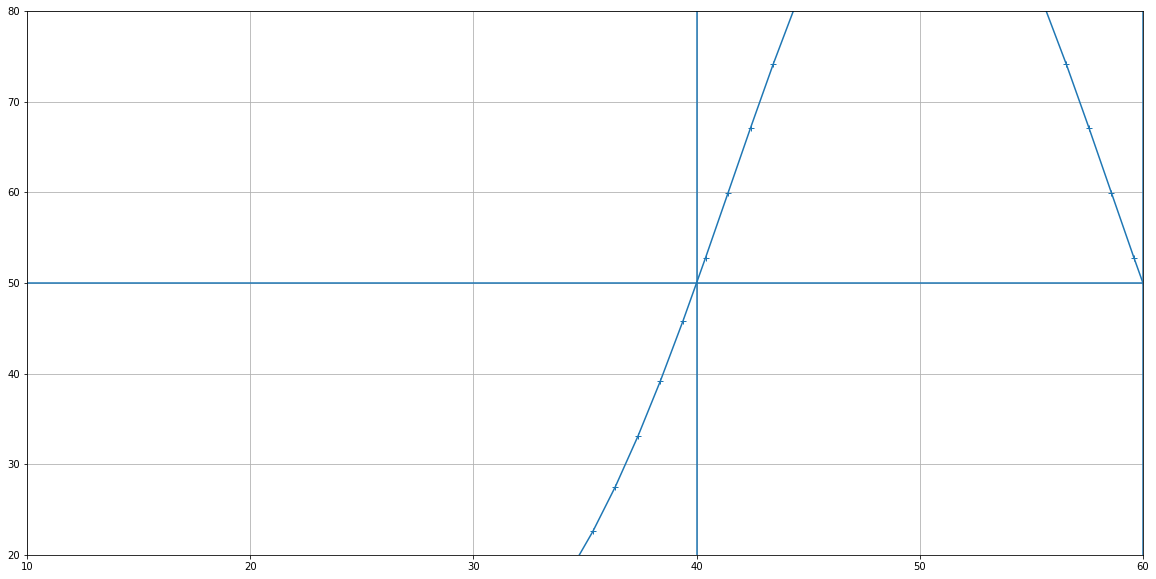

In [81]:
def gaussian(x,x0,fwhm,height):
    return height*np.exp(-(x - x0)**2/(fwhm*fwhm/2.775))
x = np.linspace(0,100,100)
y = gaussian(x,50,20,100)
plt.subplots(figsize=(20,10))
plt.plot(x,y,"+-")
plt.vlines(40,0,100)
plt.vlines(60,0,100)
plt.hlines(50,0,100)
plt.xlim(10,60)
plt.ylim(20,80)
plt.grid()